# Phishing Email Detection with Small Open LLMs: a Cross-Corpus, Leakage-Aware, Cost-Aware Benchmark

Group 18, Computer Security, United International University
Jahid Ibna Sinha, Md. Jakaria Alam Saimon, Nowshin Anjum Faria

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Jahid15/phishing-llm-cross-corpus/blob/main/notebooks/phishing_llm_cross_corpus.ipynb)

Source code: https://github.com/Jahid15/phishing-llm-cross-corpus

This notebook walks through the whole experiment. Every table and figure is read
from `results/final/`, which the scripts in `code/final/` produce. By default the
notebook only loads the saved results, so it runs in seconds. Set
`RUN_EXPERIMENTS = True` to run everything again from the raw data.

| Step | Script | What it does |
|---|---|---|
| 1 | `01_prepare_data.py` | download and clean 9 email sources |
| 2 | `02_overlap.py` | find emails shared between corpora (exact and near duplicate) |
| 3 | `03_classical_loco.py` | TF-IDF models, leave-one-corpus-out, raw vs decontaminated |
| 4 | `04_distilbert_loco.py` | fine-tuned DistilBERT, same protocol |
| 5 | `05_llm_eval.py` | six small open LLMs through OpenRouter, measured cost |
| 6 | `06_analysis.py` | final table, confidence intervals, figures |
| 7 | `07_cascade.py` | two-stage detectors built from saved predictions |
| 8 | `08_significance.py` | McNemar tests between model pairs |
| 9 | `09_placeholder.py` | the give-away token in the AI-written corpus |
| 12 | `12_offtheshelf.py` | published phishing detectors, including Phishsense |
| 13 | `13_baserate.py` | precision at a realistic amount of phishing |
| 14 | `14_label_study.py` | spam versus phishing annotation |
| 15 | `15_explanations.py` | explanation quality |
| 16 | `16_validate_matcher.py` | brute-force validation of the matcher |

In [1]:
import os, sys
IN_COLAB = "google.colab" in sys.modules
if IN_COLAB and not os.path.exists("phishing-llm-cross-corpus"):
    !git clone -q https://github.com/Jahid15/phishing-llm-cross-corpus
    %cd phishing-llm-cross-corpus
    !pip -q install datasketch
elif os.path.basename(os.getcwd()) == "notebooks":
    os.chdir("..")

RUN_EXPERIMENTS = False   # True = rerun all steps (about 1 to 2 hours, LLM step needs OPENROUTER_API_KEY)

import pandas as pd
from IPython.display import Image, display
pd.set_option("display.width", 200)
R = "results/final/"

## Step 1. Data

Six corpora that contain both phishing/spam and legitimate mail are used for
training and testing. Three more sets are only ever used for testing:
Nazario (real phishing), Nigerian fraud, and E-PhishLLM (emails written by
GPT-4o-mini, English part). Large corpora are capped at 10,000 emails with a
stratified sample (seed 42). Each set also has a fixed evaluation subset of 300
emails (150 for the one-class sets) that every model is scored on.

In [2]:
if RUN_EXPERIMENTS:
    !python code/final/01_prepare_data.py
pd.read_csv(R + "dataset_stats.csv")

,source,role,emails_after_cleaning,emails_used,phishing_or_spam,legitimate,eval_subset
0,spamassassin,train+test,5803,5803,1712,4091,300
1,ceas08,train+test,39091,10000,5574,4426,300
2,trec07,train+test,53638,10000,5460,4540,300
3,ling,train+test,2858,2858,458,2400,300
4,enron,train+test,29604,10000,4689,5311,300
5,kaggle,train+test,17505,10000,3731,6269,300
6,nazario,test only,1554,1554,1554,0,150
7,nigerian,test only,3316,3316,3316,0,150
8,ephishllm,test only,11502,10000,5213,4787,300
9,ephishllm_it,test only,2701,2701,1131,1570,300


## Step 2. How much do the corpora overlap?

Three checks, from strict to loose. `exact_raw` compares the text exactly as a
model reads it. `exact_norm` lowercases and removes all whitespace (our
preliminary method). `near` uses MinHash over 9-character shingles of the
letters and digits only, with Jaccard similarity of at least 0.8.

In [3]:
if RUN_EXPERIMENTS:
    !python code/final/02_overlap.py
pairs = pd.read_csv(R + "overlap_pairs.csv")
view = pairs[pairs.contains == "kaggle"].pivot_table(index="source", columns="level",
        values="emails_of_source_found", fill_value=0)
view["size"] = pairs[pairs.contains == "kaggle"].groupby("source").source_size.first()
print("Emails of each corpus that also appear inside the Kaggle aggregate:")
view

Emails of each corpus that also appear inside the Kaggle aggregate:


level,exact_norm,exact_raw,near,size
source,,,,
enron,187.0,3.0,10634.0,29604
ling,62.0,61.0,2600.0,2858
nigerian,0.0,0.0,71.0,3316
spamassassin,3850.0,2.0,5032.0,5803
trec07,0.0,0.0,2.0,53638


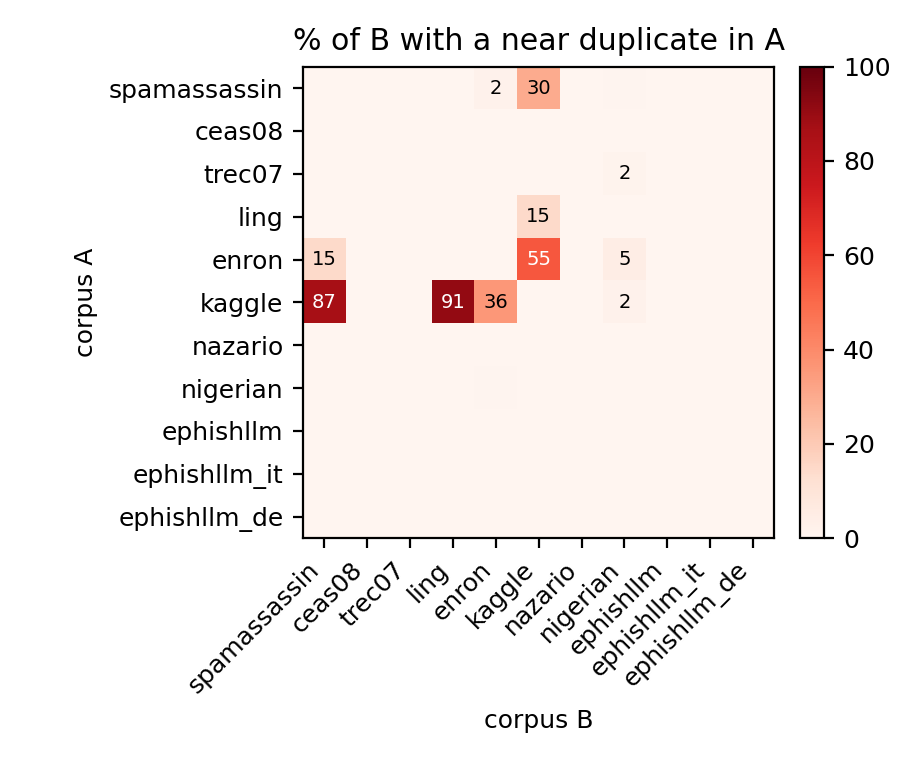

In [4]:
display(Image(R + "figures/overlap_heatmap.png", width=520))

## Step 3. Classical models, leave-one-corpus-out

For each held-out corpus the model is trained on the other five. `loco_raw`
trains on them as they are. `loco_clean` first drops every training email that
has a near duplicate in the test corpus. The difference is score inflation
caused by leaked emails.

In [5]:
if RUN_EXPERIMENTS:
    !python code/final/03_classical_loco.py
inf = pd.read_csv(R + "inflation.csv")
inf[["model", "test", "in_corpus", "loco_raw", "loco_clean", "inflation", "removed"]]

,model,test,in_corpus,loco_raw,loco_clean,inflation,removed
0,TF-IDF + LogReg,ceas08,0.9856,0.8330,0.8320,0.0010,17
1,TF-IDF + LogReg,enron,0.9810,0.9723,0.9110,0.0613,6371
2,TF-IDF + LogReg,ephishllm,NaN,0.6747,0.6747,0.0000,0
3,TF-IDF + LogReg,ephishllm_de,NaN,0.6388,0.6388,0.0000,0
4,TF-IDF + LogReg,ephishllm_it,NaN,0.5904,0.5904,0.0000,0
5,TF-IDF + LogReg,ephishllm_nolink,NaN,0.6351,0.6351,0.0000,0
6,TF-IDF + LogReg,ephishllm_url,NaN,0.6351,0.6351,0.0000,0
7,TF-IDF + LogReg,kaggle,0.9646,0.9759,0.9266,0.0493,11206
8,TF-IDF + LogReg,ling,0.9302,0.9623,0.8413,0.1210,1460
9,TF-IDF + LogReg,nazario,NaN,0.8250,0.8250,0.0000,0


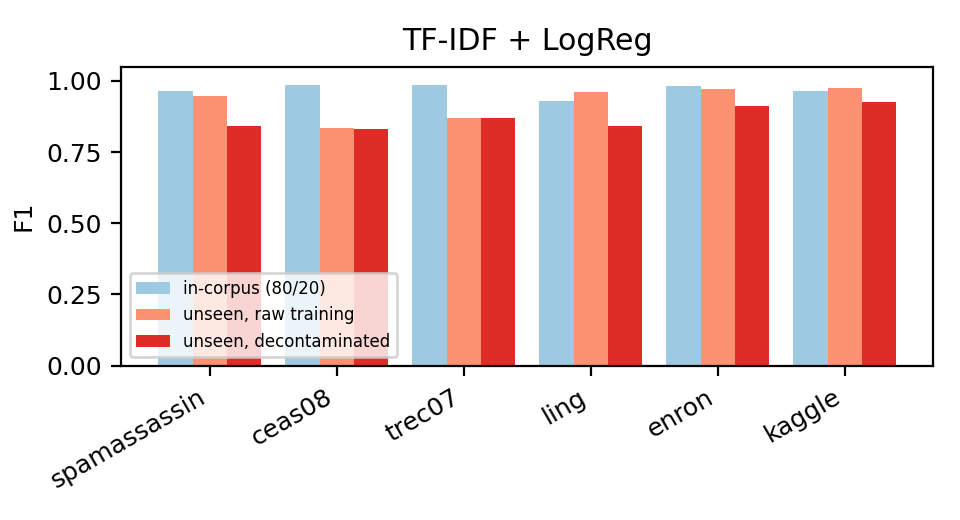

In [6]:
display(Image(R + "figures/incorpus_vs_unseen.png", width=520))

## Step 4. DistilBERT

Fine-tuned locally on the laptop CPU, 1,000 emails per training corpus,
one epoch, 128 tokens. Only the decontaminated setting is run.

In [7]:
if RUN_EXPERIMENTS:
    !python code/final/04_distilbert_loco.py
pd.read_csv(R + "distilbert_timing.csv")

,setting,test,train_size,train_sec,infer_sec_per_1000,device
0,loco_clean,nigerian,6000,465.4,17.79,cpu
1,loco_clean,ephishllm_nolink,6000,465.4,17.70,cpu
2,loco_raw,ling,5000,1855.0,29.89,cpu
3,loco_raw,spamassassin,5000,616.7,38.52,cpu
4,loco_raw,ceas08,5000,1001.1,30.83,cpu
5,loco_clean,trec07,5000,448.5,22.24,cpu
6,in_corpus,ling,2000,180.5,21.98,cpu
7,loco_clean,nazario,6000,465.4,18.17,cpu
8,loco_raw,kaggle,5000,596.5,24.31,cpu
9,in_corpus,trec07,2000,158.8,20.81,cpu


## Step 5. Small open LLMs

Zero-shot for six models and few-shot (four examples from the other corpora)
for two. Temperature 0, five output tokens, emails cut to 1,500 characters. The
cost is what OpenRouter charged for each call.

In [8]:
if RUN_EXPERIMENTS:
    !python code/final/05_llm_eval.py --mode zero --models all
pd.read_csv(R + "llm_cost.csv")

,model,usd_per_1000,usd_per_1000_all_sets,total_usd,calls,unparsed_pct,api_failed,median_latency_s,tokens_in_mean
0,Qwen-2.5-7B,0.03251,0.02713,0.09768,3600,0.00000,0,0.5890,265.32778
1,GPT-4o-mini,0.04621,0.03843,0.13834,3600,0.00000,0,1.0320,248.29500
2,Gemini-3.1-Flash-Lite,0.08004,0.06517,0.23450,3598,0.00000,0,0.9375,254.69983
3,Llama-3.2-3B few-shot AI,0.04016,0.03918,0.08228,2100,1.28571,0,0.4990,757.66667
4,Qwen-2.5-7B few-shot AI,0.07864,0.07650,0.16064,2100,0.57143,0,0.5660,759.56190
5,Llama-3.1-8B,0.01198,0.00902,0.03245,3600,0.52778,0,0.7270,265.23250
6,Phi-4-14B,0.02187,0.02078,0.04987,2400,37.08333,0,0.6020,288.03958
7,Qwen-2.5-7B few-shot,0.07503,0.07372,0.17693,2400,0.00000,0,0.6460,731.28000
8,Llama-3.2-3B,0.01711,0.01562,0.04686,3000,0.06667,0,0.5220,289.06833
9,Qwen-2.5-7B few-shot mixed,0.08343,0.08158,0.17132,2100,0.47619,0,0.5520,810.13333


## Step 6. The final table

`unseen_f1_mean` is the mean F1 over the six held-out corpora, with a 95%
bootstrap interval. `unseen_f1_worst` is the lowest of the six.
`ai_phishing_f1` is on E-PhishLLM. The two recall columns are detection rates
on real phishing (Nazario) and fraud (Nigerian). Cost is USD per 1,000 emails
(zero for local models).

In [9]:
if RUN_EXPERIMENTS:
    !python code/final/06_analysis.py
pd.read_csv(R + "main_table.csv")

,model,type,in_corpus_f1,unseen_f1_mean,unseen_f1_ci,unseen_f1_jackknife,unseen_f1_worst,false_alarm_rate,false_alarm_worst,ai_phishing_f1,nazario_recall,nigerian_recall,usd_per_1000,unparsed_pct
0,BERT-phishing (published),published detector,NaN,0.962,0.952-0.971,0.955-0.982,0.865,0.028,0.093,0.470,0.893,NaN,0.0000,0.0
1,Gemini-3.1-Flash-Lite,frontier LLM,NaN,0.960,0.950-0.968,0.955-0.973,0.892,0.017,0.033,0.950,0.987,1.000,0.0800,0.0
2,GPT-4o-mini,frontier LLM,NaN,0.950,0.939-0.961,0.944-0.961,0.895,0.043,0.060,0.917,0.987,1.000,0.0462,0.0
3,Qwen-2.5-7B few-shot mixed,small LLM,NaN,0.948,0.936-0.958,0.944-0.953,0.919,0.049,0.107,0.673,NaN,NaN,0.0834,0.5
4,Phishsense-1B (published),published detector,NaN,0.947,0.935-0.958,0.938-0.967,0.849,0.070,0.147,0.839,1.000,NaN,0.0000,0.0
5,Qwen-2.5-7B few-shot,small LLM,NaN,0.937,0.924-0.949,0.928-0.955,0.844,0.048,0.113,0.598,0.847,1.000,0.0750,0.0
6,Qwen-2.5-7B few-shot AI,small LLM,NaN,0.930,0.916-0.944,0.920-0.940,0.882,0.104,0.233,0.723,NaN,NaN,0.0786,0.6
7,Qwen-2.5-7B,small LLM,NaN,0.928,0.915-0.941,0.921-0.944,0.850,0.030,0.080,0.819,0.940,1.000,0.0325,0.0
8,Llama-3.2-3B few-shot AI,small LLM,NaN,0.903,0.886-0.919,0.889-0.919,0.827,0.099,0.173,0.649,NaN,NaN,0.0402,1.3
9,Llama-3.2-3B few-shot,small LLM,NaN,0.901,0.885-0.917,0.892-0.912,0.848,0.027,0.080,0.438,0.680,0.993,0.0378,0.0


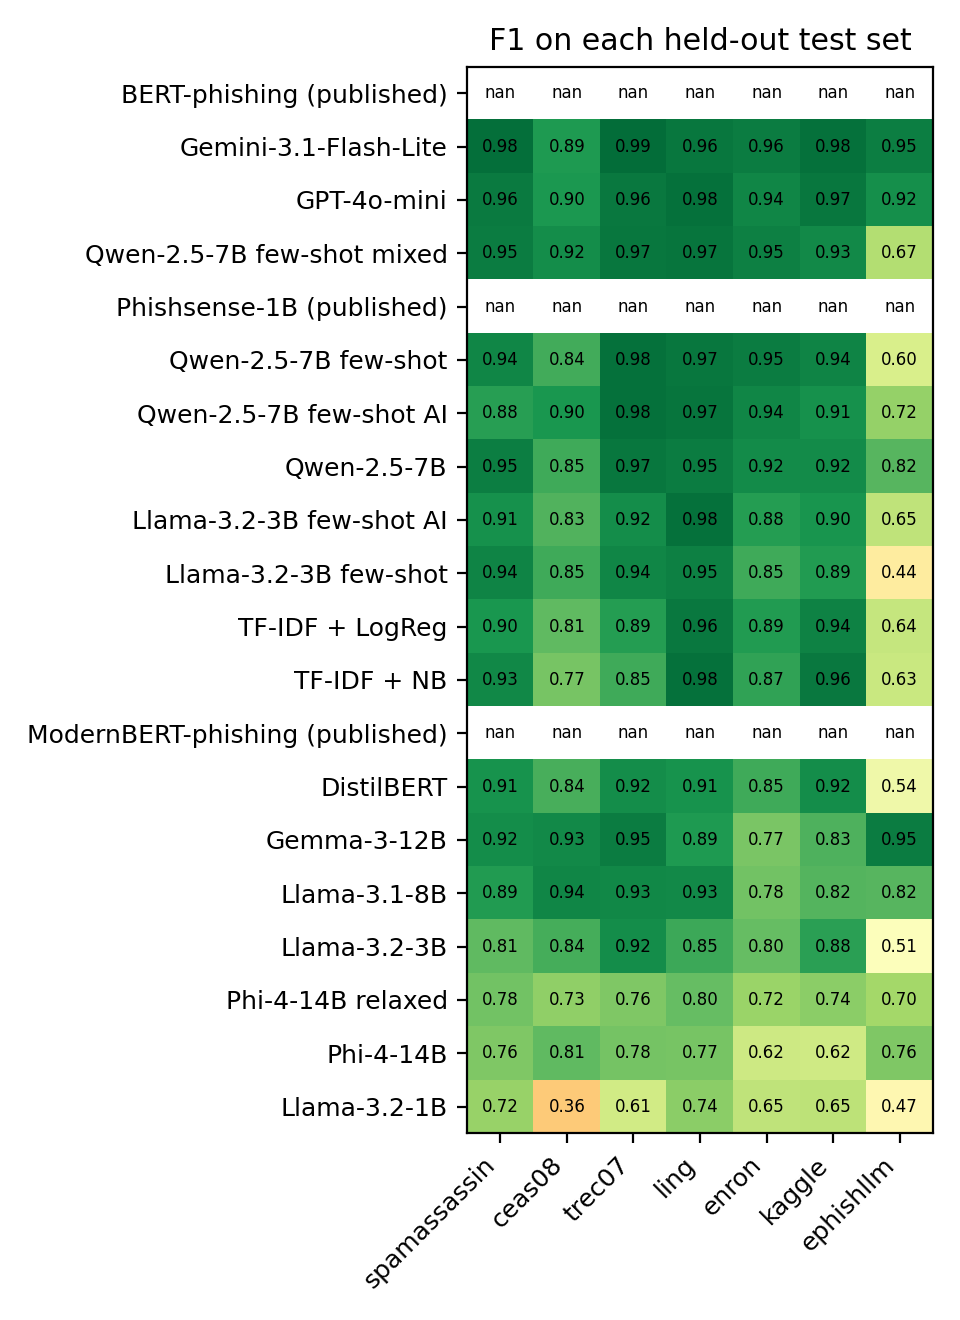

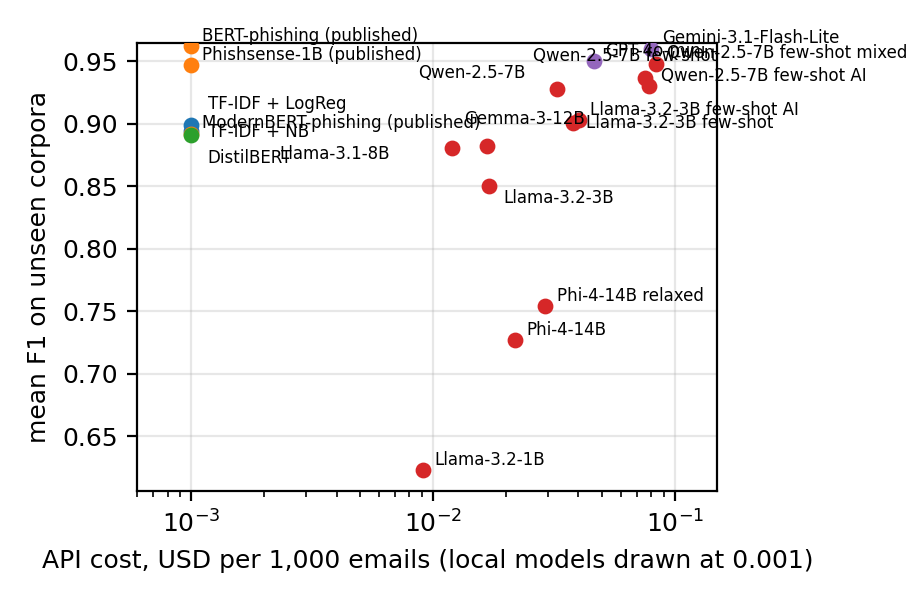

In [10]:
display(Image(R + "figures/per_corpus_f1.png", width=560))
display(Image(R + "figures/f1_vs_cost.png", width=560))

## Step 7. Is it the duplicates, or just less data?

Decontamination also shrinks the training set. The `loco_random` setting removes
the same number of training emails at random instead, so the two effects can be
told apart.

In [11]:
cl = pd.read_csv(R + "classical_loco.csv")
lr = cl[cl.model == "logreg"]
six = ["spamassassin", "ceas08", "trec07", "ling", "enron", "kaggle"]
lr.pivot_table(index="test", columns="setting", values="f1").loc[six][
    ["in_corpus_split", "loco_raw", "loco_random", "loco_clean"]].round(3)

setting,in_corpus_split,loco_raw,loco_random,loco_clean
test,,,,
spamassassin,0.966,0.947,0.947,0.840
ceas08,0.986,0.833,0.833,0.832
trec07,0.985,0.871,0.871,0.871
ling,0.930,0.962,0.960,0.841
enron,0.981,0.972,0.970,0.911
kaggle,0.965,0.976,0.972,0.927


## Step 8. What the corpora actually contain

An LLM annotator sorted every positive evaluation email into phishing or spam,
with a second annotator on 300 of them for agreement.

In [12]:
ls = pd.read_csv(R + "label_study_summary.csv")
display(ls[ls.row == "composition"][["source", "n_positives", "phishing_pct", "spam_pct"]])
display(ls[ls.row == "agreement"][["n", "agreement", "kappa"]])

,source,n_positives,phishing_pct,spam_pct
0,spamassassin,150.0,18.7,81.3
1,ceas08,150.0,14.7,85.3
2,trec07,150.0,24.7,75.3
3,ling,150.0,19.3,79.3
4,enron,150.0,21.3,78.7
5,kaggle,150.0,25.3,74.7


,n,agreement,kappa
22,300.0,0.86,0.351


## Step 9. AI-written phishing and the give-away token

E-PhishGen writes phishing links as the literal token `<<link>>`, which appears
only in phishing emails. Recall is compared on phishing emails with and without
it, and the test set is rebuilt with the token removed and replaced.

In [13]:
pd.read_csv(R + "placeholder_effect.csv").query("test_set == 'ephishllm'")[
    ["model", "recall_with_placeholder", "recall_without", "gap"]]

,model,recall_with_placeholder,recall_without,gap
0,Llama-3.2-3B few-shot AI,0.617,0.250,0.367
1,Llama-3.2-3B,0.468,0.125,0.343
2,Qwen-2.5-7B few-shot,0.543,0.232,0.310
3,Llama-3.1-8B,0.809,0.518,0.291
4,Qwen-2.5-7B few-shot mixed,0.606,0.339,0.267
5,Qwen-2.5-7B,0.777,0.554,0.223
6,Qwen-2.5-7B few-shot AI,0.649,0.429,0.220
7,Phi-4-14B,0.691,0.500,0.191
8,GPT-4o-mini,0.915,0.732,0.183
9,TF-IDF + NB,0.574,0.393,0.182


## Step 10. Operating points

Balanced test sets are not mailboxes. Precision is recomputed at a 5% phishing
rate, and two-stage detectors are built from predictions we already have.

In [14]:
display(pd.read_csv(R + "base_rate.csv")[
    ["model", "recall", "false_alarm", "precision@0.05", "f1@0.05", "false_alerts_per_1000@0.05"]].head(8))
display(pd.read_csv(R + "cascade.csv").head(6))

,model,recall,false_alarm,precision@0.05,f1@0.05,false_alerts_per_1000@0.05
0,Gemini-3.1-Flash-Lite,0.940,0.017,0.748,0.833,15.8
1,Qwen-2.5-7B,0.893,0.030,0.610,0.725,28.5
2,Llama-3.2-3B few-shot,0.844,0.027,0.625,0.718,25.3
3,GPT-4o-mini,0.946,0.043,0.535,0.683,41.2
4,Qwen-2.5-7B few-shot mixed,0.944,0.049,0.504,0.657,46.4
5,Qwen-2.5-7B few-shot,0.924,0.048,0.505,0.653,45.4
6,Llama-3.2-3B,0.778,0.051,0.445,0.566,48.6
7,DistilBERT,0.857,0.063,0.416,0.560,60.2


,stage1,stage2,policy,unseen_f1,unseen_recall,false_alarm,ai_phishing_f1,ai_phishing_recall,share_to_stage2,usd_per_1000
0,Gemma-3-12B,Qwen-2.5-7B,confirm,0.929,0.891,0.027,0.819,0.693,0.614,0.0366
1,Qwen-2.5-7B,Gemma-3-12B,confirm,0.929,0.891,0.027,0.819,0.693,0.462,0.0402
2,Llama-3.1-8B,Qwen-2.5-7B,confirm,0.914,0.866,0.027,0.760,0.613,0.581,0.0309
3,TF-IDF + LogReg,Gemma-3-12B,confirm,0.914,0.884,0.047,0.750,0.620,0.497,0.0083
4,TF-IDF + LogReg,Qwen-2.5-7B,confirm,0.911,0.848,0.011,0.678,0.513,0.497,0.0161
5,TF-IDF + LogReg,Qwen-2.5-7B,rescue,0.916,0.943,0.114,0.753,0.813,0.503,0.0164


## Step 11. Are the differences real?

McNemar tests on the paired predictions, and the paired bootstrap difference
for the comparisons the paper makes.

In [15]:
display(pd.read_csv(R + "significance.csv").head(8))
import os
if os.path.exists(R + "paired_differences.csv"):
    display(pd.read_csv(R + "paired_differences.csv"))

,model_a,model_b,scope,n,a_correct_only,b_correct_only,acc_a,acc_b,p_value,significant_at_0.05
0,Qwen-2.5-7B,TF-IDF + LogReg,six unseen corpora,1800,117,62,0.9317,0.9011,4.790000e-05,True
1,Qwen-2.5-7B,TF-IDF + LogReg,AI-written (E-PhishLLM),300,79,18,0.8467,0.6433,2.720000e-10,True
2,Qwen-2.5-7B,DistilBERT,six unseen corpora,1800,114,51,0.9317,0.8967,1.040000e-06,True
3,Qwen-2.5-7B,DistilBERT,AI-written (E-PhishLLM),300,80,12,0.8467,0.6200,1.720000e-13,True
4,Qwen-2.5-7B,Gemma-3-12B,six unseen corpora,1800,204,80,0.9317,0.8628,1.180000e-13,True
5,Qwen-2.5-7B,Gemma-3-12B,AI-written (E-PhishLLM),300,12,44,0.8467,0.9533,2.090000e-05,True
6,Qwen-2.5-7B,Llama-3.1-8B,six unseen corpora,1800,194,77,0.9317,0.8667,8.090000e-13,True
7,Qwen-2.5-7B,Llama-3.1-8B,AI-written (E-PhishLLM),300,14,13,0.8467,0.8433,1.000000e+00,False


,model_a,model_b,mean_difference,ci_low,ci_high,excludes_zero
0,Qwen-2.5-7B,TF-IDF + LogReg,0.0292,0.0156,0.0444,True
1,Qwen-2.5-7B,DistilBERT,0.0371,0.0238,0.0524,True
2,Qwen-2.5-7B few-shot,Qwen-2.5-7B,0.0085,-0.0010,0.0183,False
3,Gemma-3-12B,Qwen-2.5-7B,-0.0468,-0.0703,-0.0249,True
4,Gemini-3.1-Flash-Lite,Qwen-2.5-7B,0.0319,0.0198,0.0435,True


## What to take away

See `paper/main.pdf` for the discussion, `TEAM_GUIDE.md` for a full explanation
of every decision, and `RESEARCH_LOG.md` for the story of how the project
developed, including the mistakes.